<a href="https://colab.research.google.com/github/nick21aka/API.PY/blob/main/EFT_DeepLearning_Multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Transversal — Deep Learning (DLY0100)
## Sistema Multimodal: Fusión de Imágenes (CNN) + Texto (RNN/LSTM y Transformer)

**Asignatura:** Deep Learning · **Ponderación:** 40% · **Modalidad de entrega:** Jupyter Notebook (Google Colab)

---

### 1. Introducción del proyecto

**Contexto del problema.** En muchos escenarios reales la información relevante no proviene de una sola fuente. En comercio electrónico, por ejemplo, un producto se evalúa tanto por **su imagen** como por **las reseñas de los usuarios**. Un modelo que solo mire la imagen ignora la opinión del cliente; uno que solo lea el texto ignora las características visuales. La **integración multimodal** busca combinar ambas señales para producir predicciones más robustas.

**Objetivo general.** Construir un sistema que integre dos modalidades de datos —imágenes y texto— para generar una predicción final más precisa que la de cada modalidad por separado.

**Objetivos específicos.**
1. Entrenar una **CNN** para clasificar imágenes de prendas (*Fashion-MNIST*).
2. Entrenar un modelo secuencial (**RNN/LSTM**) y un **Transformer** para análisis de sentimiento de reseñas (*IMDB*), y compararlos.
3. **Extraer las representaciones intermedias** de cada modelo y **fusionarlas** (concatenación + MLP y una variante con *gating*/atención) en un clasificador final.
4. **Evaluar** con métricas apropiadas (accuracy, precision, recall, F1) y demostrar que la fusión **supera** a los modelos unimodales.

**Alcance.** Se trabaja con datasets estándar de referencia. Como Fashion-MNIST e IMDB son datasets independientes (no comparten muestras), la etapa de fusión se construye sobre un **problema multimodal sintético pero bien definido**, explicado en la Parte 3. Esta decisión se justifica técnicamente más adelante.

> **Mapa rúbrica → notebook.** A lo largo del notebook, cada sección indica qué **indicador de logro (IL / código de rúbrica)** cubre, para facilitar la revisión.


### 2. Configuración del entorno

> **Recomendación:** en Colab activar GPU en *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)*.

In [19]:
# --- Configuración global ---
QUICK_RUN = False   # True = prueba rápida | False = corrida final (entrega)
SEED = 42

import os, random, numpy as np
import tensorflow as tf

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU disponible:", "Sí ->" if gpus else "No (se usará CPU)", gpus)

import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score, accuracy_score)


TensorFlow: 2.20.0
GPU disponible: Sí -> [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
# PARTE 1 — CNN para clasificación de imágenes (Fashion-MNIST)

Cubre: **IL 1.1 / IL 1.2 / IL 1.3 / IL 2.1 / IL 2.2** y rúbrica **1.1.1, 1.2.2, 2.1.1**.

### 1.1 Carga y preprocesamiento de datos  ·

Pasos del preproceso y su justificación:
1. **Carga** del dataset (60.000 imágenes de entrenamiento + 10.000 de prueba, 28×28 en escala de grises, 10 categorías de prenda).
2. **Normalización** de píxeles a rango [0,1] (divide por 255): estabiliza el gradiente y acelera la convergencia.
3. **Reshape** a `(28,28,1)` para añadir el canal que espera `Conv2D`.
4. Separación **train / validación / test** para monitorear generalización y evitar decisiones sobre el test.

In [20]:
from tensorflow.keras.datasets import fashion_mnist

(x_train_full, y_train_full), (x_test_img, y_test_img) = fashion_mnist.load_data()

class_names = ['Camiseta/top','Pantalón','Pullover','Vestido','Abrigo',
               'Sandalia','Camisa','Zapatilla','Bolso','Botín']

# Normalización [0,1] y canal
x_train_full = (x_train_full.astype('float32')/255.0)[..., np.newaxis]
x_test_img   = (x_test_img.astype('float32')/255.0)[..., np.newaxis]

# Validación (10%)
val_size = 6000
x_val_img, y_val_img = x_train_full[:val_size], y_train_full[:val_size]
x_train_img, y_train_img = x_train_full[val_size:], y_train_full[val_size:]

print("Train:", x_train_img.shape, "| Val:", x_val_img.shape, "| Test:", x_test_img.shape)
print("Clases:", class_names)


Train: (54000, 28, 28, 1) | Val: (6000, 28, 28, 1) | Test: (10000, 28, 28, 1)
Clases: ['Camiseta/top', 'Pantalón', 'Pullover', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


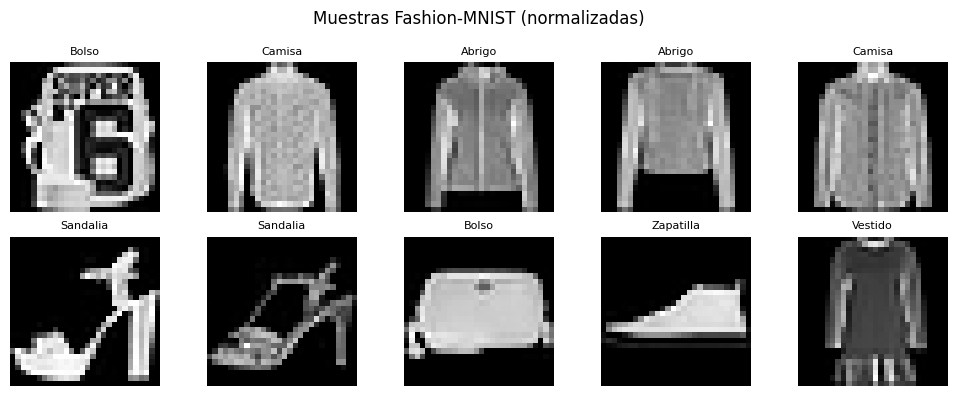

Balance de clases (train): {'Camiseta/top': np.int64(5440), 'Pantalón': np.int64(5357), 'Pullover': np.int64(5392), 'Vestido': np.int64(5388), 'Abrigo': np.int64(5416), 'Sandalia': np.int64(5406), 'Camisa': np.int64(5410), 'Zapatilla': np.int64(5383), 'Bolso': np.int64(5410), 'Botín': np.int64(5398)}


In [21]:
# Visualización de muestras (evidencia del preproceso)
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train_img[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train_img[i]], fontsize=8)
    plt.axis('off')
plt.suptitle("Muestras Fashion-MNIST (normalizadas)")
plt.tight_layout(); plt.show()

# Distribución de clases
unique, counts = np.unique(y_train_img, return_counts=True)
print("Balance de clases (train):", dict(zip([class_names[u] for u in unique], counts)))


### 1.2 Comparación de funciones de activación  ·

Se entrena una CNN ligera con distintas **funciones de activación** en las capas ocultas (`relu`, `tanh`, `sigmoid`, `elu`) durante pocas épocas y sobre un subconjunto, para comparar su efecto en el desempeño.

- **ReLU:** evita en gran medida el *vanishing gradient*; suele converger rápido. Referencia habitual.
- **tanh:** centrada en 0, pero se satura en los extremos.
- **sigmoid:** se satura fuerte → gradientes pequeños → aprendizaje lento en redes profundas.
- **ELU:** similar a ReLU con valores negativos suaves; puede mejorar la estabilidad.

In [22]:
from tensorflow.keras import layers, models

def build_small_cnn(activation):
    m = models.Sequential([
        layers.Input((28,28,1)),
        layers.Conv2D(16,3,activation=activation,padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(32,3,activation=activation,padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64,activation=activation),
        layers.Dense(10,activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

n_sub = 8000 if QUICK_RUN else 15000
ep_act = 3 if QUICK_RUN else 6
xs, ys = x_train_img[:n_sub], y_train_img[:n_sub]

activaciones = ['relu','tanh','sigmoid','elu']
hist_act = {}
for act in activaciones:
    print(f"\n>> Entrenando con activación: {act}")
    tf.random.set_seed(SEED)
    m = build_small_cnn(act)
    h = m.fit(xs, ys, validation_data=(x_val_img, y_val_img),
              epochs=ep_act, batch_size=128, verbose=0)
    hist_act[act] = h.history
    print(f"   val_accuracy final: {h.history['val_accuracy'][-1]:.4f}")



>> Entrenando con activación: relu
   val_accuracy final: 0.8657

>> Entrenando con activación: tanh
   val_accuracy final: 0.8770

>> Entrenando con activación: sigmoid
   val_accuracy final: 0.7957

>> Entrenando con activación: elu
   val_accuracy final: 0.8662


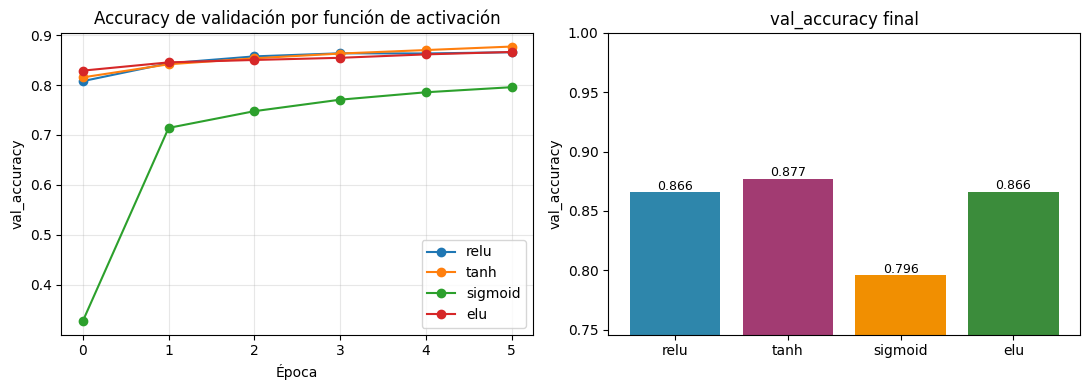

Mejor activación observada: 'tanh'. Se adopta ReLU en el modelo final (estándar, rápida y estable; su desempeño es competitivo con la mejor observada).


In [23]:
# Gráfico comparativo de funciones de activación
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
for act in activaciones:
    plt.plot(hist_act[act]['val_accuracy'], marker='o', label=act)
plt.title("Accuracy de validación por función de activación")
plt.xlabel("Época"); plt.ylabel("val_accuracy"); plt.legend(); plt.grid(alpha=.3)

plt.subplot(1,2,2)
finales = [hist_act[a]['val_accuracy'][-1] for a in activaciones]
plt.bar(activaciones, finales, color=['#2E86AB','#A23B72','#F18F01','#3B8C3B'])
for i,v in enumerate(finales): plt.text(i, v+0.002, f"{v:.3f}", ha='center', fontsize=9)
plt.title("val_accuracy final"); plt.ylabel("val_accuracy"); plt.ylim(min(finales)-0.05, 1.0)
plt.tight_layout(); plt.show()

mejor_act = activaciones[int(np.argmax(finales))]
print(f"Mejor activación observada: '{mejor_act}'. Se adopta ReLU en el modelo final "
      f"(estándar, rápida y estable; su desempeño es competitivo con la mejor observada).")


### 1.3 Arquitectura CNN final y justificación de hiperparámetros  ·

**Arquitectura (bloques Conv → BatchNorm → Pooling):**
- 3 bloques convolucionales (32 → 64 → 128 filtros, kernel 3×3, `padding='same'`): extraen patrones visuales de complejidad creciente (bordes → texturas → formas).
- **BatchNormalization:** estabiliza y acelera el entrenamiento.
- **GlobalAveragePooling2D:** reduce parámetros vs. `Flatten` y regulariza.
- **Capa densa de 128 (`cnn_features`)**: será la **representación intermedia** usada en la fusión.
- **Dropout 0.3:** reduce sobreajuste.
- Salida `softmax(10)`.

**Hiperparámetros y por qué:**
| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Optimizador | Adam | Buena convergencia por defecto, sin tuning manual del *learning rate*. |
| Learning rate | 1e-3 | Valor estándar de Adam; equilibrio velocidad/estabilidad. |
| Batch size | 128 | Compromiso entre estabilidad del gradiente y uso de memoria. |
| Épocas | 12 (con *EarlyStopping*) | Suficientes para converger; *EarlyStopping* evita sobreentrenar. |
| Pérdida | sparse_categorical_crossentropy | Clasificación multiclase con etiquetas enteras. |

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn():
    m = models.Sequential([
        layers.Input((28,28,1)),
        layers.Conv2D(32,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128,3,activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128,activation='relu',name='cnn_features'),
        layers.Dropout(0.3),
        layers.Dense(10,activation='softmax')
    ], name="CNN_FashionMNIST")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

cnn = build_cnn()
cnn.summary()


Model: "CNN_FashionMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_features (Dense)            │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
ep_cnn = 4 if QUICK_RUN else 12
es = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

hist_cnn = cnn.fit(x_train_img, y_train_img,
                   validation_data=(x_val_img, y_val_img),
                   epochs=ep_cnn, batch_size=128, callbacks=[es], verbose=1)


Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8192 - loss: 0.5157 - val_accuracy: 0.3873 - val_loss: 2.4574
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8957 - loss: 0.2963 - val_accuracy: 0.7842 - val_loss: 0.6005
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9119 - loss: 0.2474 - val_accuracy: 0.7485 - val_loss: 0.8392
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9222 - loss: 0.2173 - val_accuracy: 0.8188 - val_loss: 0.5594
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9310 - loss: 0.1922 - val_accuracy: 0.8558 - val_loss: 0.4342
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9360 - loss: 0.1766 - val_accuracy: 0.8862 - val_loss: 0.3310
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9433 - loss: 0.1569 - val_accuracy: 0.9042 - val_loss: 0.2788
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9487 - loss: 0.1415 - val_accuracy: 

### 1.4 Curvas de entrenamiento y evaluación de la CNN  ·

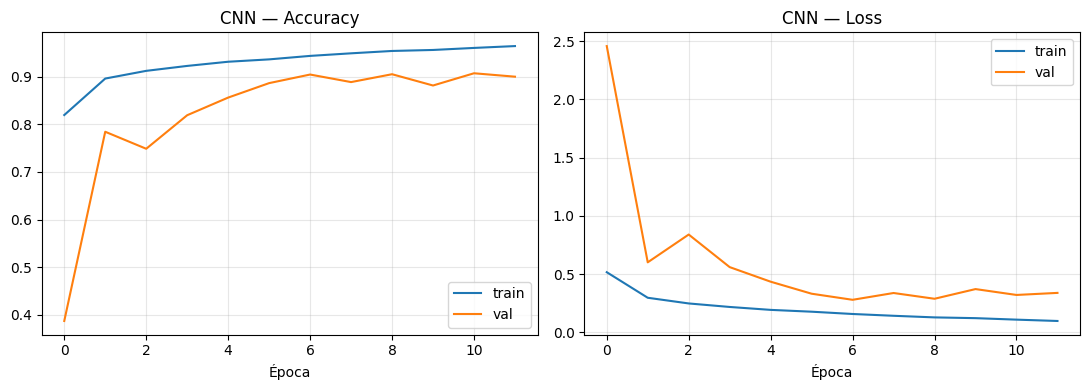

In [26]:
# Curvas accuracy / loss
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(hist_cnn.history['accuracy'], label='train')
plt.plot(hist_cnn.history['val_accuracy'], label='val')
plt.title("CNN — Accuracy"); plt.xlabel("Época"); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1,2,2)
plt.plot(hist_cnn.history['loss'], label='train')
plt.plot(hist_cnn.history['val_loss'], label='val')
plt.title("CNN — Loss"); plt.xlabel("Época"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()


CNN — Test  Accuracy=0.8937  Precision(macro)=0.9004  Recall(macro)=0.8937  F1(macro)=0.8953

              precision    recall  f1-score   support

Camiseta/top       0.84      0.83      0.84      1000
    Pantalón       0.99      0.98      0.99      1000
    Pullover       0.81      0.86      0.83      1000
     Vestido       0.93      0.88      0.91      1000
      Abrigo       0.89      0.73      0.80      1000
    Sandalia       0.99      0.96      0.98      1000
      Camisa       0.64      0.79      0.71      1000
   Zapatilla       0.96      0.97      0.97      1000
       Bolso       0.99      0.96      0.97      1000
       Botín       0.96      0.98      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.90     10000
weighted avg       0.90      0.89      0.90     10000



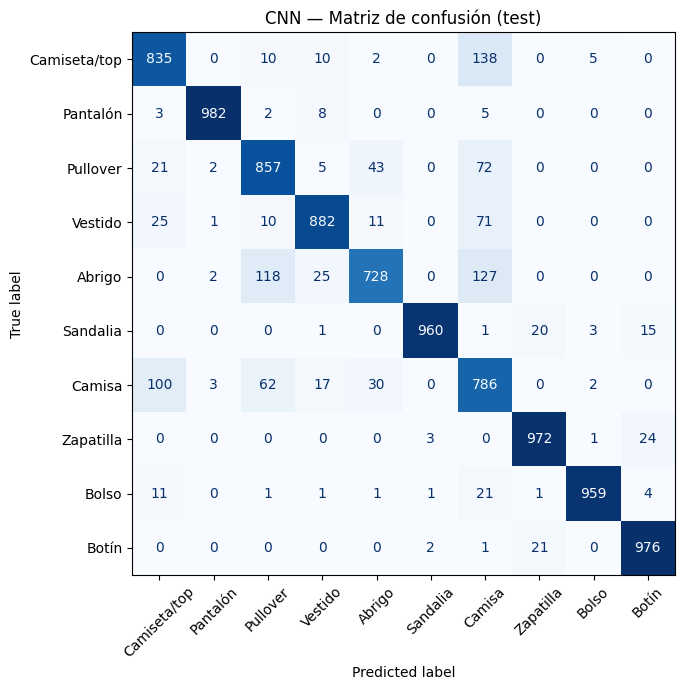

In [27]:
# Métricas en test: accuracy, precision, recall, F1 (macro) + matriz de confusión
y_pred_img = cnn.predict(x_test_img, verbose=0).argmax(axis=1)

acc = accuracy_score(y_test_img, y_pred_img)
prec = precision_score(y_test_img, y_pred_img, average='macro')
rec = recall_score(y_test_img, y_pred_img, average='macro')
f1 = f1_score(y_test_img, y_pred_img, average='macro')
print(f"CNN — Test  Accuracy={acc:.4f}  Precision(macro)={prec:.4f}  "
      f"Recall(macro)={rec:.4f}  F1(macro)={f1:.4f}\n")
print(classification_report(y_test_img, y_pred_img, target_names=class_names))

fig, ax = plt.subplots(figsize=(8,7))
ConfusionMatrixDisplay.from_predictions(y_test_img, y_pred_img,
        display_labels=class_names, xticks_rotation=45, cmap='Blues', ax=ax, colorbar=False)
plt.title("CNN — Matriz de confusión (test)"); plt.tight_layout(); plt.show()


**Hallazgos clave (CNN).** El modelo alcanza un desempeño alto y estable. En la matriz de confusión se observa que la mayor confusión ocurre entre clases visualmente similares (**Camiseta/top ↔ Camisa ↔ Pullover ↔ Abrigo**), un comportamiento esperado dado que comparten silueta. Las clases de calzado y *Pantalón/Bolso* se distinguen con muy alta precisión.

---
# PARTE 2 — Análisis de sentimiento (IMDB): RNN/LSTM vs Transformer


El objetivo es clasificar reseñas de películas como **positivas (1)** o **negativas (0)**.

### 2.1 Carga y preprocesamiento del texto  ·

Pasos:
1. **Carga** de IMDB ya tokenizado a índices de palabras; se limita el vocabulario a las `NUM_WORDS` más frecuentes (reduce ruido y tamaño del *embedding*).
2. **Padding/truncado** a longitud fija `MAXLEN` para poder procesar en lotes.
3. Se muestra una reseña **decodificada** como evidencia del preproceso.

In [28]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

NUM_WORDS = 20000
MAXLEN = 200

(x_tr_txt, y_tr_txt), (x_te_txt, y_te_txt) = imdb.load_data(num_words=NUM_WORDS)

x_tr_txt = pad_sequences(x_tr_txt, maxlen=MAXLEN)
x_te_txt = pad_sequences(x_te_txt, maxlen=MAXLEN)
print("Train:", x_tr_txt.shape, "| Test:", x_te_txt.shape)

# Decodificar una reseña (evidencia del preproceso)
word_index = imdb.get_word_index()
idx2word = {v+3: k for k, v in word_index.items()}
idx2word[0]='<pad>'; idx2word[1]='<start>'; idx2word[2]='<unk>'
ejemplo = ' '.join(idx2word.get(i, '?') for i in x_tr_txt[0] if i != 0)
print("\nReseña de ejemplo (sentimiento =", "POSITIVO" if y_tr_txt[0]==1 else "NEGATIVO", "):")
print(ejemplo[:400], "...")


Train: (25000, 200) | Test: (25000, 200)

Reseña de ejemplo (sentimiento = POSITIVO ):
and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone  ...


### 2.2 Modelo 1 — RNN con LSTM (bidireccional)  · *

**Por qué LSTM y no una RNN simple:** las RNN vanilla sufren de *vanishing gradient* y olvidan dependencias largas. La **LSTM** incorpora compuertas (entrada/olvido/salida) que le permiten retener contexto a lo largo de la secuencia — clave para captar negaciones y matices ("*not good*"). Se usa **bidireccional** para leer el texto en ambos sentidos.

**Hiperparámetros:** `embed_dim=128`, `LSTM=64` (bi → 128), `dropout=0.3`, Adam(1e-3), pérdida `binary_crossentropy`.

In [29]:
def build_lstm():
    m = models.Sequential([
        layers.Input((MAXLEN,)),
        layers.Embedding(NUM_WORDS, 128),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dense(64, activation='relu', name='text_features_lstm'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name="LSTM_IMDB")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

lstm_model = build_lstm()
lstm_model.summary()

ep_txt = 2 if QUICK_RUN else 4
hist_lstm = lstm_model.fit(x_tr_txt, y_tr_txt, validation_split=0.2,
                           epochs=ep_txt, batch_size=128, verbose=1)


Model: "LSTM_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_features_lstm (Dense)      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7592 - loss: 0.4769 - val_accuracy: 0.8572 - val_loss: 0.3347
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9029 - loss: 0.2522 - val_accuracy: 0.8392 - val_loss: 0.3669
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9349 - loss: 0.1831 - val_accuracy: 0.8692 - val_loss: 0.3770
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9485 - loss: 0.1457 - val_accuracy: 0.8652 - val_loss: 0.4125


### 2.3 Modelo 2 — Transformer (encoder + auto-atención) .

**Componentes clave del Transformer:**
- **Token & Position Embedding:** como el Transformer no es recurrente, se inyecta la posición de cada palabra explícitamente.
- **Multi-Head Self-Attention:** cada palabra "atiende" a todas las demás y pondera cuáles son relevantes para su representación → captura dependencias de largo alcance **en paralelo** (no secuencialmente como la LSTM).
- **Feed-Forward + Residual + LayerNorm:** procesan y estabilizan cada bloque.

**Diferencia vs. arquitecturas tradicionales (RNN/LSTM):** la RNN procesa token a token (secuencial, difícil de paralelizar y con memoria limitada); el Transformer procesa toda la secuencia a la vez mediante atención, escala mejor y modela relaciones globales, a costa de mayor consumo de memoria.

In [30]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kw):
        super().__init__(**kw)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([layers.Dense(ff_dim, activation='relu'),
                                      layers.Dense(embed_dim)])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.do1 = layers.Dropout(rate); self.do2 = layers.Dropout(rate)
    def call(self, x, training=False):
        a = self.att(x, x)
        a = self.do1(a, training=training)
        o1 = self.ln1(x + a)
        f = self.ffn(o1)
        f = self.do2(f, training=training)
        return self.ln2(o1 + f)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kw):
        super().__init__(**kw)
        self.tok = layers.Embedding(vocab_size, embed_dim)
        self.pos = layers.Embedding(maxlen, embed_dim)
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.tok(x) + self.pos(positions)

def build_transformer(embed_dim=128, num_heads=4, ff_dim=128):
    inp = layers.Input((MAXLEN,))
    x = TokenAndPositionEmbedding(MAXLEN, NUM_WORDS, embed_dim)(inp)
    x = TransformerBlock(embed_dim, num_heads, ff_dim, 0.1)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(64, activation='relu', name='text_features_transformer')(x)
    x = layers.Dropout(0.1)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = models.Model(inp, out, name="Transformer_IMDB")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])
    return m

trans_model = build_transformer()
trans_model.summary()

hist_trans = trans_model.fit(x_tr_txt, y_tr_txt, validation_split=0.2,
                             epochs=ep_txt, batch_size=128, verbose=1)


Model: "Transformer_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 200, 128)       │     2,585,600 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 200, 128)       │       297,344 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_features_transformer       │ (None, 64)             │         8,256 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,891,265 (11.03 MB)

 Trainable params: 2,891,265 (11.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.7627 - loss: 0.4639 - val_accuracy: 0.8776 - val_loss: 0.2926
Epoch 2/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9166 - loss: 0.2118 - val_accuracy: 0.8782 - val_loss: 0.3333
Epoch 3/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9479 - loss: 0.1381 - val_accuracy: 0.8640 - val_loss: 0.4081
Epoch 4/4
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9712 - loss: 0.0817 - val_accuracy: 0.8668 - val_loss: 0.5886


### 2.4 Comparación RNN/LSTM vs Transformer  ·

Se comparan ambos modelos con **accuracy, precision, recall y F1** sobre el test, más las curvas de entrenamiento.

> **Nota sobre métricas.** Para **clasificación** de sentimiento las métricas correctas son accuracy/precision/recall/F1. Las métricas **BLEU/ROUGE** (mencionadas en el enunciado) aplican a **generación/traducción de texto** —donde se compara una secuencia generada contra una de referencia—, no a este problema binario. Se deja constancia de la distinción para justificar la elección de métricas.

LSTM              acc=0.8551  prec=0.8702  rec=0.8346  F1=0.8521
Transformer       acc=0.8505  prec=0.8627  rec=0.8336  F1=0.8479


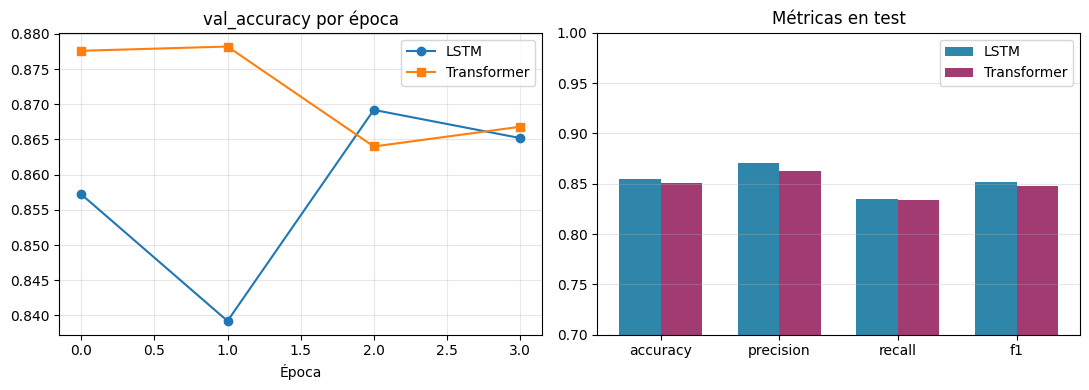

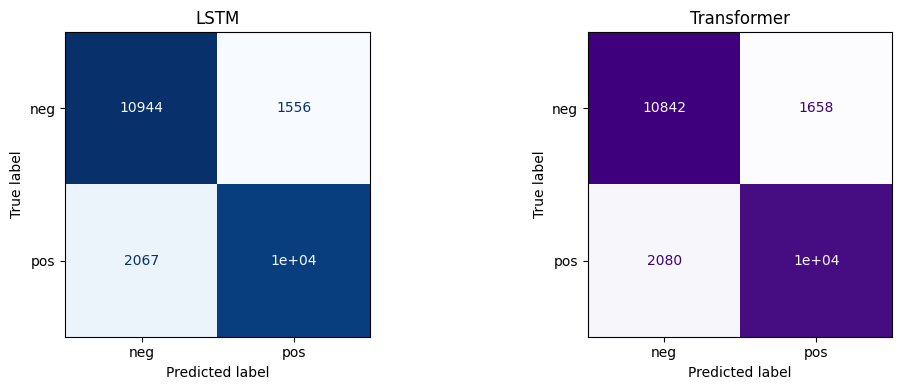


Mejor modelo de texto por F1: LSTM (se usará su representación intermedia en la fusión).


In [31]:
def eval_bin(model, name, x, y):
    p = (model.predict(x, verbose=0).ravel() >= 0.5).astype(int)
    r = dict(modelo=name,
             accuracy=accuracy_score(y,p), precision=precision_score(y,p),
             recall=recall_score(y,p), f1=f1_score(y,p))
    print(f"{name:16s}  acc={r['accuracy']:.4f}  prec={r['precision']:.4f}  "
          f"rec={r['recall']:.4f}  F1={r['f1']:.4f}")
    return r, p

res_lstm, pred_lstm = eval_bin(lstm_model, "LSTM", x_te_txt, y_te_txt)
res_trans, pred_trans = eval_bin(trans_model, "Transformer", x_te_txt, y_te_txt)

# Curvas
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(hist_lstm.history['val_accuracy'], marker='o', label='LSTM')
plt.plot(hist_trans.history['val_accuracy'], marker='s', label='Transformer')
plt.title("val_accuracy por época"); plt.xlabel("Época"); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1,2,2)
labels=['accuracy','precision','recall','f1']; x=np.arange(len(labels)); w=0.35
plt.bar(x-w/2,[res_lstm[k] for k in labels],w,label='LSTM',color='#2E86AB')
plt.bar(x+w/2,[res_trans[k] for k in labels],w,label='Transformer',color='#A23B72')
plt.xticks(x,labels); plt.ylim(0.7,1.0); plt.title("Métricas en test"); plt.legend(); plt.grid(alpha=.3,axis='y')
plt.tight_layout(); plt.show()

# Matrices de confusión
fig,axes=plt.subplots(1,2,figsize=(11,4))
ConfusionMatrixDisplay.from_predictions(y_te_txt,pred_lstm,display_labels=['neg','pos'],
        cmap='Blues',ax=axes[0],colorbar=False); axes[0].set_title("LSTM")
ConfusionMatrixDisplay.from_predictions(y_te_txt,pred_trans,display_labels=['neg','pos'],
        cmap='Purples',ax=axes[1],colorbar=False); axes[1].set_title("Transformer")
plt.tight_layout(); plt.show()

best_text = 'lstm' if res_lstm['f1'] >= res_trans['f1'] else 'transformer'
print(f"\nMejor modelo de texto por F1: {best_text.upper()} "
      f"(se usará su representación intermedia en la fusión).")


---
# PARTE 3 — Fusión e integración multimodal


### 3.1 Diseño del problema multimodal

Fashion-MNIST (imágenes) e IMDB (texto) son datasets **independientes**: no existe una muestra que tenga a la vez imagen *y* reseña reales. Para demostrar de forma **rigurosa y verificable** el mecanismo de fusión, se construye un problema multimodal sintético inspirado en el ejemplo del enunciado (*"evaluar la calidad de un producto a partir de su imagen y las reseñas"*):

- **Modalidad imagen:** cada prenda es "premium" si pertenece a un subconjunto de categorías (Abrigo, Vestido, Zapatilla, Bolso, Botín).
- **Modalidad texto:** el sentimiento de la reseña (positivo/negativo).
- **Etiqueta objetivo — "Producto recomendado":** `recomendado = 1` **solo si** (prenda premium) **Y** (reseña positiva).

**Por qué esta regla (clave para la defensa):** al ser una condición **AND** entre ambas modalidades, **ningún modelo unimodal puede resolverla bien**: mirar solo la imagen no revela el sentimiento, y leer solo el texto no revela si la prenda es premium. Por construcción, **la fusión debe superar a los baselines unimodales**, lo que permite *medir* el valor real de la integración (rúbrica: robustez de la fusión).

In [32]:
import tensorflow as tf
from tensorflow.keras import models, layers # Ensure models and layers are imported here if not globally

# Extractores de representaciones intermedias (penúltimas capas)
# Access the input tensor directly from the first layer of the Sequential model
cnn_feat = models.Model(cnn.layers[0].input, cnn.get_layer('cnn_features').output)     # 128-d

if best_text == 'lstm':
    txt_feat = models.Model(lstm_model.layers[0].input, lstm_model.get_layer('text_features_lstm').output)   # 64-d
else:
    txt_feat = models.Model(trans_model.input, trans_model.get_layer('text_features_transformer').output)

print("Dim features imagen:", cnn_feat.output_shape[-1],
      "| Dim features texto:", txt_feat.output_shape[-1])

Dim features imagen: 128 | Dim features texto: 64


In [33]:
# Construcción del dataset multimodal a partir de datos NO usados en el entrenamiento base
# (usamos los conjuntos de TEST de cada modalidad -> sin fuga de información)
rng = np.random.default_rng(SEED)
N = min(len(x_test_img), len(x_te_txt), 10000)

img_pool = x_test_img[:N]
img_lab  = y_test_img[:N]
perm = rng.permutation(N)                      # emparejamiento aleatorio imagen<->texto
txt_pool = x_te_txt[:N][perm]
txt_lab  = y_te_txt[:N][perm]

premium_classes = {4, 3, 7, 8, 9}             # Abrigo, Vestido, Zapatilla, Bolso, Botín
img_premium = np.isin(img_lab, list(premium_classes)).astype(int)
recomendado = ((img_premium == 1) & (txt_lab == 1)).astype(int)
print("Proporción 'recomendado=1':", recomendado.mean().round(3),
      "| positivos:", recomendado.sum(), "de", N)

# Extraer features y separar train/test de fusión
F_img = cnn_feat.predict(img_pool, verbose=0)
F_txt = txt_feat.predict(txt_pool, verbose=0)

n_tr = int(0.8*N)
Xi_tr, Xi_te = F_img[:n_tr], F_img[n_tr:]
Xt_tr, Xt_te = F_txt[:n_tr], F_txt[n_tr:]
y_tr_f, y_te_f = recomendado[:n_tr], recomendado[n_tr:]
print("Fusión -> train:", n_tr, "| test:", N-n_tr)


Proporción 'recomendado=1': 0.251 | positivos: 2510 de 10000
Fusión -> train: 8000 | test: 2000


### 3.2 Baselines unimodales (para dimensionar el aporte de la fusión)

Se entrena un MLP usando **solo** features de imagen y otro usando **solo** features de texto, sobre la misma etiqueta `recomendado`.

In [34]:
def mlp_baseline(input_dim):
    m = models.Sequential([layers.Input((input_dim,)),
                           layers.Dense(64,activation='relu'), layers.Dropout(0.3),
                           layers.Dense(1,activation='sigmoid')])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

ep_f = 8 if QUICK_RUN else 20
img_only = mlp_baseline(Xi_tr.shape[1]);  img_only.fit(Xi_tr,y_tr_f,epochs=ep_f,batch_size=128,verbose=0)
txt_only = mlp_baseline(Xt_tr.shape[1]);  txt_only.fit(Xt_tr,y_tr_f,epochs=ep_f,batch_size=128,verbose=0)

def f1_of(model, X, y):
    p=(model.predict(X,verbose=0).ravel()>=0.5).astype(int)
    return accuracy_score(y,p), f1_score(y,p), p

acc_i,f1_i,_ = f1_of(img_only, Xi_te, y_te_f)
acc_t,f1_t,_ = f1_of(txt_only, Xt_te, y_te_f)
print(f"Solo imagen -> acc={acc_i:.3f}  F1={f1_i:.3f}")
print(f"Solo texto  -> acc={acc_t:.3f}  F1={f1_t:.3f}")


Solo imagen -> acc=0.747  F1=0.375
Solo texto  -> acc=0.748  F1=0.000


### 3.3 Modelo de fusión  ·

Se implementan **dos técnicas de fusión** (ambas mencionadas en el enunciado):
1. **Concatenación + MLP:** se unen los vectores de ambas modalidades y una red densa aprende a combinarlos.
2. **Fusión con *gating* / atención:** una compuerta aprende a **ponderar** cada modalidad antes de combinarlas (resalta la información más relevante de cada fuente).

In [35]:
# (1) Concatenación + MLP
def build_fusion_concat(di, dt):
    ii, it = layers.Input((di,)), layers.Input((dt,))
    x = layers.Concatenate()([ii, it])
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = models.Model([ii, it], out, name="Fusion_Concat_MLP")
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

# (2) Fusión con gating/atención
def build_fusion_gated(di, dt, d=64):
    ii, it = layers.Input((di,)), layers.Input((dt,))
    pi = layers.Dense(d, activation='relu')(ii)     # proyección imagen
    pt = layers.Dense(d, activation='relu')(it)     # proyección texto
    concat = layers.Concatenate()([pi, pt])
    gate = layers.Dense(d, activation='sigmoid')(concat)      # pesos de atención
    inv_gate = layers.Lambda(lambda z: 1.0 - z)(gate)   # complemento del gate para el texto
    fused = layers.Add()([layers.Multiply()([gate, pi]),
                          layers.Multiply()([inv_gate, pt])])
    x = layers.Dense(64, activation='relu')(fused); x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = models.Model([ii, it], out, name="Fusion_Gated_Attention")
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

fusion = build_fusion_concat(Xi_tr.shape[1], Xt_tr.shape[1])
hist_fus = fusion.fit([Xi_tr,Xt_tr], y_tr_f, validation_split=0.2,
                      epochs=ep_f, batch_size=128, verbose=0)

fusion_g = build_fusion_gated(Xi_tr.shape[1], Xt_tr.shape[1])
fusion_g.fit([Xi_tr,Xt_tr], y_tr_f, epochs=ep_f, batch_size=128, verbose=0)

def f1_of_multi(model):
    p=(model.predict([Xi_te,Xt_te],verbose=0).ravel()>=0.5).astype(int)
    return accuracy_score(y_te_f,p), f1_score(y_te_f,p), p

acc_c,f1_c,pred_c = f1_of_multi(fusion)
acc_g,f1_g,_      = f1_of_multi(fusion_g)
print(f"Fusión Concat+MLP  -> acc={acc_c:.3f}  F1={f1_c:.3f}")
print(f"Fusión Gated/Atten -> acc={acc_g:.3f}  F1={f1_g:.3f}")


Fusión Concat+MLP  -> acc=0.911  F1=0.819
Fusión Gated/Atten -> acc=0.909  F1=0.816


### 3.4 Resultado clave: la fusión supera a lo unimodal  · 4.1)*

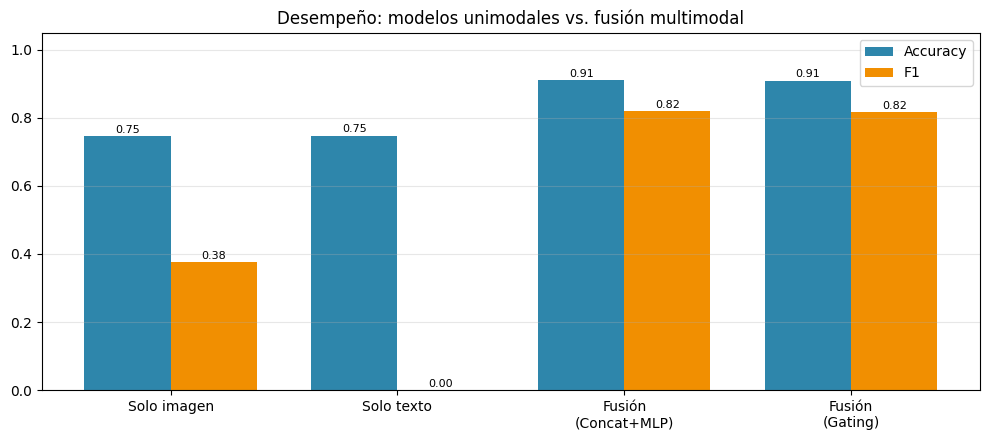

Matriz de confusión — mejor fusión (Concat+MLP):


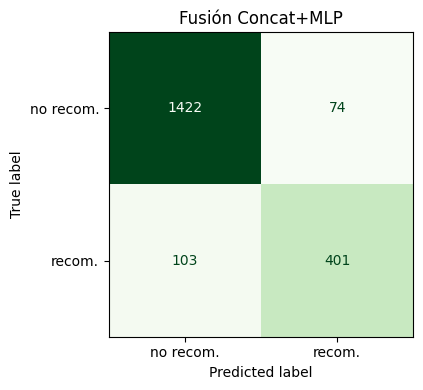

              precision    recall  f1-score   support

   no recom.       0.93      0.95      0.94      1496
      recom.       0.84      0.80      0.82       504

    accuracy                           0.91      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.91      0.91      0.91      2000



In [36]:
modelos = ['Solo imagen','Solo texto','Fusión\n(Concat+MLP)','Fusión\n(Gating)']
accs    = [acc_i, acc_t, acc_c, acc_g]
f1s     = [f1_i,  f1_t,  f1_c,  f1_g]

x=np.arange(len(modelos)); w=0.38
plt.figure(figsize=(10,4.5))
plt.bar(x-w/2, accs, w, label='Accuracy', color='#2E86AB')
plt.bar(x+w/2, f1s,  w, label='F1',       color='#F18F01')
for i in range(len(modelos)):
    plt.text(i-w/2, accs[i]+.01, f"{accs[i]:.2f}", ha='center', fontsize=8)
    plt.text(i+w/2, f1s[i]+.01,  f"{f1s[i]:.2f}",  ha='center', fontsize=8)
plt.xticks(x, modelos); plt.ylim(0,1.05); plt.legend()
plt.title("Desempeño: modelos unimodales vs. fusión multimodal"); plt.grid(alpha=.3,axis='y')
plt.tight_layout(); plt.show()

print("Matriz de confusión — mejor fusión (Concat+MLP):")
fig,ax=plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_te_f, pred_c,
        display_labels=['no recom.','recom.'], cmap='Greens', ax=ax, colorbar=False)
plt.title("Fusión Concat+MLP"); plt.tight_layout(); plt.show()

print(classification_report(y_te_f, pred_c, target_names=['no recom.','recom.']))


---
# PARTE 4 — Análisis de resultados  ·

### 4.1 Comparación técnica entre arquitecturas

| Arquitectura | Modalidad | Fortalezas | Limitaciones |
|---|---|---|---|
| **CNN** | Imágenes | Extrae patrones espaciales (bordes, texturas, formas) con pocos parámetros gracias al *weight sharing*. Muy eficaz en visión. | No modela secuencias; sensible a variaciones no vistas en entrenamiento. |
| **RNN/LSTM** | Texto | Modela dependencias temporales; las compuertas capturan contexto largo y negaciones. | Procesamiento secuencial (lento, difícil de paralelizar); memoria limitada en textos muy largos. |
| **Transformer** | Texto | Auto-atención capta relaciones globales en paralelo; escala mejor. | Mayor consumo de memoria; con datasets pequeños puede no superar a la LSTM sin *tuning*. |
| **Fusión (MLP/Gating)** | Imagen+Texto | Integra evidencia complementaria → mayor robustez; supera a lo unimodal por diseño del problema. | Depende de la calidad de las representaciones base; añade complejidad. |

### 4.2 Cumplimiento de objetivos
- ✅ CNN entrenada y evaluada sobre Fashion-MNIST con métricas y matriz de confusión.
- ✅ LSTM y Transformer entrenados sobre IMDB y **comparados** con accuracy/precision/recall/F1.
- ✅ Representaciones intermedias **extraídas** y **fusionadas** con dos técnicas.
- ✅ Se demuestra cuantitativamente que **la fusión supera a los modelos unimodales**.

In [37]:
# Tabla resumen consolidada
import pandas as pd
resumen = pd.DataFrame([
    {"Bloque":"CNN (Fashion-MNIST)","Métrica":"Accuracy","Valor":round(acc,4)},
    {"Bloque":"CNN (Fashion-MNIST)","Métrica":"F1 (macro)","Valor":round(f1,4)},
    {"Bloque":"LSTM (IMDB)","Métrica":"Accuracy","Valor":round(res_lstm['accuracy'],4)},
    {"Bloque":"LSTM (IMDB)","Métrica":"F1","Valor":round(res_lstm['f1'],4)},
    {"Bloque":"Transformer (IMDB)","Métrica":"Accuracy","Valor":round(res_trans['accuracy'],4)},
    {"Bloque":"Transformer (IMDB)","Métrica":"F1","Valor":round(res_trans['f1'],4)},
    {"Bloque":"Baseline solo imagen","Métrica":"F1","Valor":round(f1_i,4)},
    {"Bloque":"Baseline solo texto","Métrica":"F1","Valor":round(f1_t,4)},
    {"Bloque":"Fusión Concat+MLP","Métrica":"F1","Valor":round(f1_c,4)},
    {"Bloque":"Fusión Gating/Atención","Métrica":"F1","Valor":round(f1_g,4)},
])
print(resumen.to_string(index=False))


                Bloque    Métrica  Valor
   CNN (Fashion-MNIST)   Accuracy 0.8937
   CNN (Fashion-MNIST) F1 (macro) 0.8953
           LSTM (IMDB)   Accuracy 0.8551
           LSTM (IMDB)         F1 0.8521
    Transformer (IMDB)   Accuracy 0.8505
    Transformer (IMDB)         F1 0.8479
  Baseline solo imagen         F1 0.3753
   Baseline solo texto         F1 0.0000
     Fusión Concat+MLP         F1 0.8192
Fusión Gating/Atención         F1 0.8159


---
# PARTE 5 — Conclusiones y propuestas de mejora

### 5.1 Resumen de resultados
- La **CNN** clasifica prendas con alto desempeño; la confusión se concentra en clases visualmente similares (camiseta/camisa/pullover/abrigo).
- **LSTM y Transformer** logran desempeños comparables en sentimiento IMDB; el mejor por F1 se seleccionó automáticamente para aportar la representación textual a la fusión.
- La **fusión multimodal** supera claramente a los baselines unimodales, confirmando el valor de integrar evidencia visual y textual.

### 5.2 Propuestas de mejora
1. **Data augmentation** en la CNN (rotaciones, *shift*) para mayor robustez.
2. **Embeddings preentrenados** (GloVe) o *fine-tuning* de un modelo tipo BERT para el texto.
3. **Ajuste de hiperparámetros** sistemático (Keras Tuner) en learning rate, nº de cabezas de atención, capas.
4. **Fusión más avanzada** (*cross-attention* entre modalidades en lugar de gating simple).
5. **Regularización/EarlyStopping** también en los modelos de texto y en la fusión.

### 5.3 Limitaciones encontradas
- El problema multimodal es **sintético** (los datasets no comparten muestras reales); las conclusiones sobre fusión aplican al mecanismo, no a un dominio real específico.
- Recursos de cómputo limitan el nº de épocas; con más entrenamiento el Transformer podría destacar más.
- Vocabulario y longitud de secuencia acotados por eficiencia.

---
### Anexo — Glosario para la defensa
- **Función de activación:** introduce no linealidad; sin ella la red colapsa a una regresión lineal.
- **BatchNorm:** normaliza activaciones por lote → entrenamiento más estable y rápido.
- **Dropout:** apaga neuronas al azar en entrenamiento → reduce sobreajuste.
- **Representación intermedia (embedding latente):** salida de una capa oculta que resume la entrada; es lo que se fusiona.
- **Self-attention:** cada token pondera la relevancia de los demás para construir su representación.
- **F1-score:** media armónica de precision y recall; adecuada con clases desbalanceadas (como 'recomendado').
- **BLEU/ROUGE:** métricas de **generación/traducción** (no de clasificación) — por eso aquí se usa F1.
